In [1]:
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import ndimage


Binary mask: binary_mask_thr0.0179.nii.gz  (25,005 voxels)
Subject    : newAcq_9f22896dfd43ed54
Shape      : (88, 1024, 1024)  (z, y, x)
Unc range  : [0.0000, 0.4057]


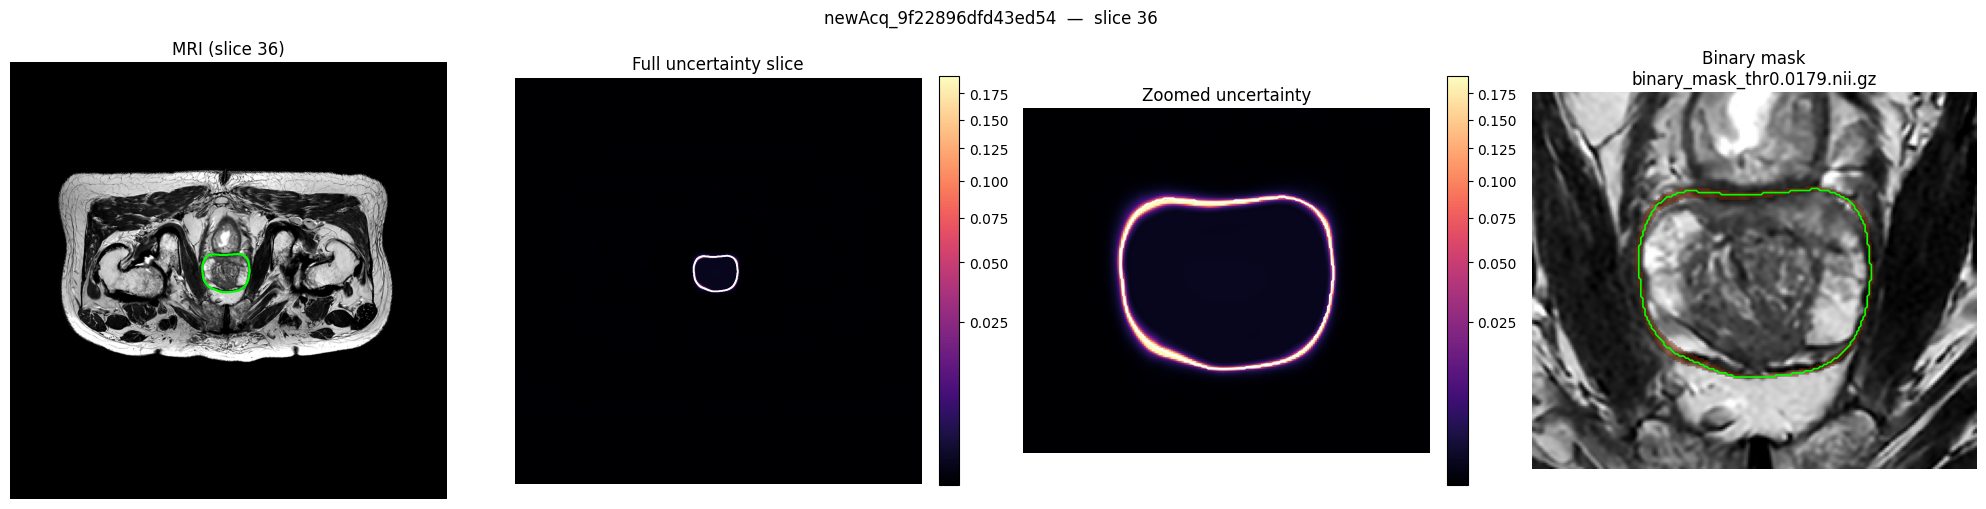

In [82]:
from matplotlib.colors import PowerNorm

# ── Change subject_index to load a different case ─────────────────────────────
project_root  = Path.cwd()
data_root     = project_root / "data" / "LUNDPROBE" / "ExtendedSamples"
subject_index = 19
image_folder  = "MR_StorT2"
# ─────────────────────────────────────────────────────────────────────────────

subjects  = sorted([p.name for p in data_root.iterdir() if p.is_dir()])
case_dir  = data_root / subjects[subject_index] / image_folder

img_itk       = sitk.ReadImage(str(case_dir / "image.nii.gz"))
pred_mask_itk = sitk.ReadImage(str(case_dir / "nnUNetOutput/mask_CTVT_427_nnUNet.nii.gz"))
unc_itk       = sitk.ReadImage(str(case_dir / "nnUNetOutput/mask_CTVT_427_nnUNet_uncertaintyMap.nii.gz"))

img         = sitk.GetArrayFromImage(img_itk).astype(np.float32)
pred_mask   = (sitk.GetArrayFromImage(pred_mask_itk) > 0).astype(np.uint8)
uncertainty = sitk.GetArrayFromImage(unc_itk).astype(np.float32)

# ── Load saved binary mask (most recent one saved from Napari) ────────────────
saved_masks  = sorted((case_dir / "nnUNetOutput").glob("binary_mask_thr*.nii.gz"))
binary_mask  = None
mask_label   = "none"
if saved_masks:
    mask_path   = saved_masks[-1]
    binary_mask = sitk.GetArrayFromImage(sitk.ReadImage(str(mask_path))).astype(bool)
    mask_label  = mask_path.name
    print(f"Binary mask: {mask_label}  ({binary_mask.sum():,} voxels)")
else:
    print("No saved binary mask found — run the Napari viewer and press 'Save binary mask' first.")

print(f"Subject    : {subjects[subject_index]}")
print(f"Shape      : {uncertainty.shape}  (z, y, x)")
print(f"Unc range  : [{uncertainty.min():.4f}, {uncertainty.max():.4f}]")

# ── Pick the slice with the most segmentation voxels ─────────────────────────
seg_slices = np.where(pred_mask.any(axis=(1, 2)))[0]
sl = int(seg_slices[len(seg_slices) // 2]) if len(seg_slices) else uncertainty.shape[0] // 2

unc_sl   = uncertainty[sl]
seg_sl   = pred_mask[sl].astype(bool)
img_sl   = img[sl]
mask_sl  = binary_mask[sl] if binary_mask is not None else None

# Zoom tightly around the segmentation
if seg_sl.any():
    ys, xs = np.where(seg_sl)
    cy, cx = int(ys.mean()), int(xs.mean())
    half_h = max(64, int((ys.max() - ys.min()) * 0.75) + 24)
    half_w = max(64, int((xs.max() - xs.min()) * 0.75) + 24)
else:
    cy, cx = unc_sl.shape[0] // 2, unc_sl.shape[1] // 2
    half_h = half_w = 80

y0 = max(0, cy - half_h);  y1 = min(unc_sl.shape[0], cy + half_h)
x0 = max(0, cx - half_w);  x1 = min(unc_sl.shape[1], cx + half_w)
crop = (slice(y0, y1), slice(x0, x1))

unc_crop  = unc_sl[crop]
seg_crop  = seg_sl[crop]
img_crop  = img_sl[crop]
mask_crop = mask_sl[crop] if mask_sl is not None else None

img_vmin, img_vmax = np.percentile(img_crop, [1, 99])
nonzero  = unc_crop[unc_crop > 0]
unc_vmin = float(np.percentile(nonzero, 1))  if nonzero.size else 0.0
unc_vmax = float(np.percentile(nonzero, 99)) if nonzero.size else 1.0
unc_norm = PowerNorm(gamma=0.45, vmin=unc_vmin, vmax=unc_vmax)

ncols = 4 if binary_mask is not None else 3
fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 5))

# Panel 1 — MRI + segmentation contour
axes[0].imshow(img_sl, cmap="gray", origin="lower", vmin=img_vmin, vmax=img_vmax)
if seg_sl.any():
    axes[0].contour(seg_sl.astype(float), levels=[0.5], colors="lime", linewidths=1.5)
axes[0].set_title(f"MRI (slice {sl})")
axes[0].axis("off")

# Panel 2 — full uncertainty slice
im1 = axes[1].imshow(unc_sl, cmap="magma", origin="lower", norm=unc_norm)
if seg_sl.any():
    axes[1].contour(seg_sl.astype(float), levels=[0.5], colors="white", linewidths=1.2)
axes[1].set_title("Full uncertainty slice")
axes[1].axis("off")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# Panel 3 — zoomed uncertainty
im2 = axes[2].imshow(unc_crop, cmap="magma", origin="lower", norm=unc_norm)
if seg_crop.any():
    axes[2].contour(seg_crop.astype(float), levels=[0.5], colors="white", linewidths=1.2)
axes[2].set_title("Zoomed uncertainty")
axes[2].axis("off")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

# Panel 4 — binary mask overlay (only if loaded)
if mask_crop is not None:
    axes[3].imshow(img_crop, cmap="gray", origin="lower", vmin=img_vmin, vmax=img_vmax)
    axes[3].imshow(np.where(mask_crop, 1.0, np.nan),
                   cmap="Oranges", alpha=0.5, origin="lower", vmin=0, vmax=1)
    if seg_crop.any():
        axes[3].contour(seg_crop.astype(float), levels=[0.5], colors="lime", linewidths=1.2)
    axes[3].set_title(f"Binary mask\n{mask_label}")
    axes[3].axis("off")

plt.suptitle(f"{subjects[subject_index]}  —  slice {sl}", y=1.01)
plt.tight_layout()
plt.show()
